In [ ]:
import matplotlib.pyplot as plt

# Model Tuning

## Recap from Under the hood..

**problem setting**
- $X$ = features
- $y$ = target = $h(X, \color{blue}{\beta}) + error$
- $h$ = hypothesis function (Linear, Logistic Regression, ...)

**Parameters of the model: $\color{blue}{\beta}$**
- computed automatically during `.fit()`
- by minimizing $L(\color{blue}{\beta})$

**Hyperparameters of the model**
(chosen manually)
- loss function $L$ (MSE, Log-Loss,...)
- loss-parameters of the loss (learning_rate, eta0...)
- solver = method used to miminize $L$ ('newton', 'sdg', ...)
- model-specificities ('n_neighbors', 'kernel' ...)
- ...

# Plan

1. Model complexity
2. Regularization
3. Model Tuning: Grid Search & Random Search
4. Support Vector Machines (Margin Classifiers)
5. Kernel Tricks

## The tuning stage

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/roadmap_evaluate.png" width="700"/>

## 1. Model complexity

Let's remember Linear Regression:

$ Y = \beta_0 + \beta_1 X_1 + \epsilon $



❓What about non-linear behavior as below?

<img src="https://animoidin.files.wordpress.com/2018/07/polim_vs_linear.jpg" style="width:400px;">

👉 If we add a new transformed feature $ X_1^2 $ we have a better fit (in red)

$ Y = \beta_0 + \beta_1 X_1 + \beta_2 X_1^2 + ... + \epsilon $

🤔 We could engineer very complex features: $ X^3, X^6, (X_1^2 * X_2^5), ... $

Our $ R^2 $ will keep increasing with every additional feature!

> We just solved Data Science!

```python
def train_best_model_ever(X,y):
    while True:
        model = LinearRegression()
        model.fit(X, y)
        if calculate_r2(model, X, y) < 0.999999:
            X = add_more_crazy_features(X)
        else:
            return model
```

(We will actually learn a clever trick to automatically "add_more_crazy_features" later in the kernel section!)

Do you see any problem with this?

### Overfitting and Underfitting

<img src='https://wagon-public-datasets.s3.amazonaws.com/05-Machine-Learning/05-Model-Tuning/overfit-underfit.png' width=700>

What's wrong with the first model? With the third?

- The first does not capture all the information in the data (**high bias** model). 

- The third finds signal that isn't there (noise). It will not generalize well to new data points.  
(**high variance** model: It will vary a lot from dataset to dataset)

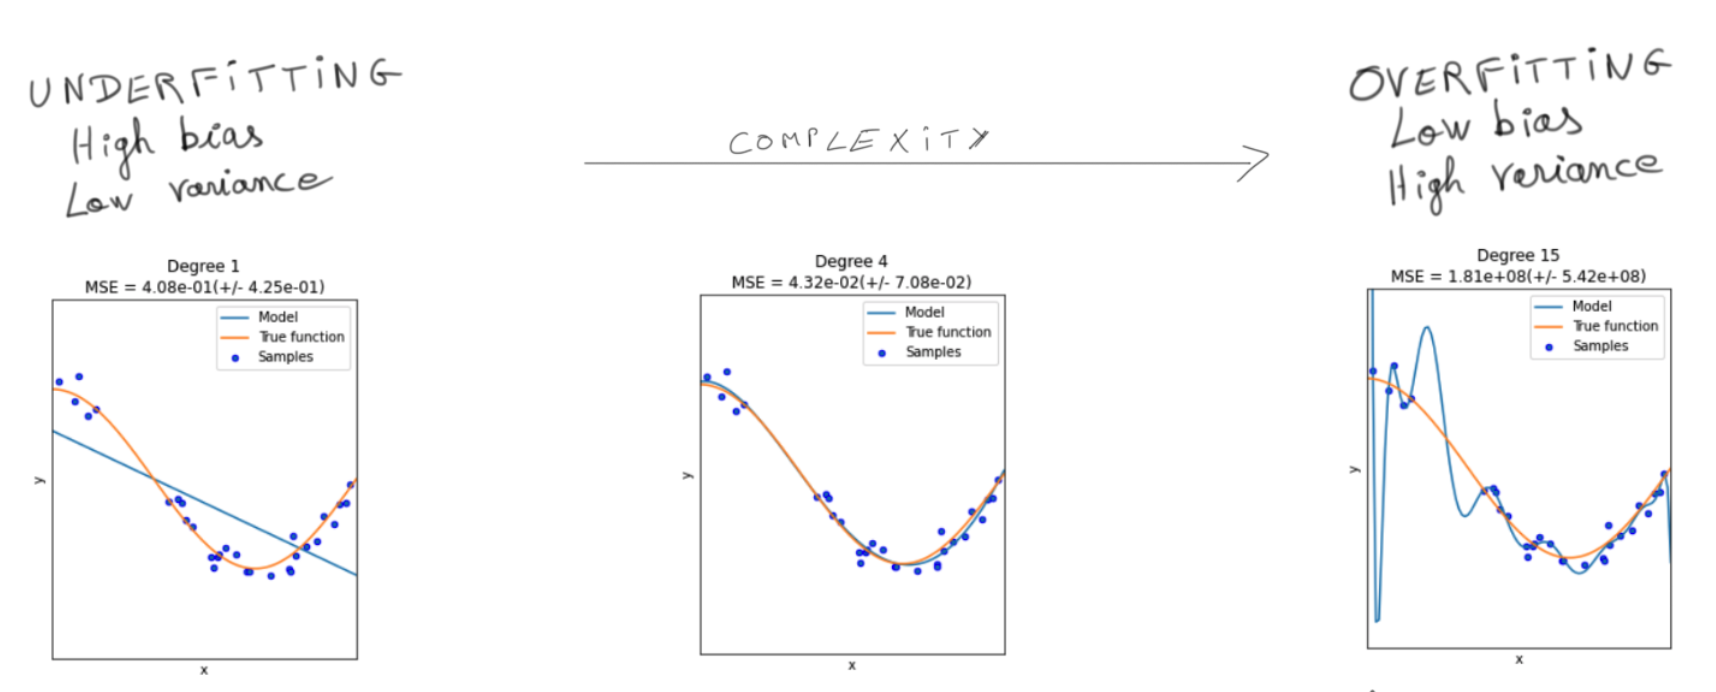

### The Bias-Variance Tradeoff 

One of the most important concepts in Data Science!

Look at what happens in reality when measuring the error on an unseen **Test set**: 

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/biasvariancetradeoff.png">

$ TotalError = \color{red}{Bias^2} + \color{teal}{Variance} + \color{grey}{Irreducible Error} $

📚 [Great read](http://scott.fortmann-roe.com/docs/BiasVariance.html)

❓How do we find the optimal model complexity?

The one that minimizes the **Test Error** on an unseen dataset

<img src='https://datacadamia.com/_media/data_mining/model_complexity_error_training_test.jpg' width=600>

🤔 Don't have time to try many models?

Use **learning curves** to at least diagnose the only one you have! 

<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/model_tuning_learning-curves.png'>

❗️Data Leak❗️ Diagnose your model using a **Validation Set** instead!  

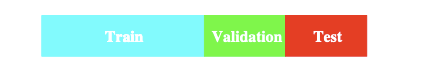

👉 **Cross-validate** instead of using a single holdout val set to generalize better!

$ Y = f(X) + \epsilon $

- Y is the true value for the target 
- f(X) is the "true" relationship of X and Y for the available data X
- $ \epsilon $ is the "irreducible error" 

If we had **ALL THE DATA IN THE WORLD**, $\epsilon$ would be zero. But for any given realistic dataset, there is an irreducible error, even with the perfect model f(X)

We now make guesses for the true function $ f(X) $: $\hat{Y} = \hat{f}(X) $

$\hat{Y}$ contains **reducible** errors that come from the model not being perfect even for the given data X:

Error of the prediction = Bias of Model + Variance of Model + Irreducible Error

(Intuition only! The true mathematical relationship is a bit more complex)

### Solutions for Overfitting

> _Simplify_ your model _relative_ to your data

- Get more observations
- Feature selection (manual or [automated](https://scikit-learn.org/stable/modules/feature_selection.html))
- Dimensionality reduction (Unsupervised Learning)
- Early stopping (Deep Learning)
- **Regularization** of your Loss function

## 2. Regularization

Regularization means adding a **penalty term** to the Loss that **increases** with $\color{blue}{\beta}$

  
$$Regularized Loss = Loss(X,y, \color{blue}{\beta}\color{black}{)} + Penalty(\color{blue}{\beta})$$


👉 Penalizes large values for $\beta_i$  
👉 Forces model to shrink certain coefficients or even select less features  
👉 Prevents overfitting


$$\hat{y} =  \color{blue}{\beta_0} + \color{blue}{\beta_1} X_1 + \color{blue}{\beta_2} X_1^2 + \color{blue}{\beta_3} X_1^3 + ... $$

The two most famous Regularization penalties are:


- **Ridge** (L2) 


$$\begin{equation}
\operatorname{Ridge}(\color{green}{X},
                     \color{magenta}{y},
                     \color{blue}{\boldsymbol{\beta}}
                     \color{black}{)}
=
\underbrace{\sum_{i=0}^{n-1}
  \Bigl(\color{magenta}{y_i} \color{black}{-}
        \bigl(\color{blue}{\beta_0}
            \color{black}{+} \color{blue}{\beta_1}\color{green}{x_1}
            \color{black}{+} \dots
            \color{black}{+} \color{blue}{\beta_p}\color{green}{x_p} \color{black}{\bigr)}
  \Bigr)^{2}}_{\text{Loss}(\color{green}{X},
                            \color{magenta}{y},
                            \color{blue}{\boldsymbol{\beta}})}
\;+\;
\color{red}{\alpha} \color{black}{\sum_{\color{green}{j=1}}^{\color{green}{p}}}\color{blue}{\beta_j^{2}}.
\end{equation}$$





- **Lasso** (L1) 

$$\begin{equation}
\operatorname{Lasso}(\color{green}{X},
                     \color{magenta}{y},
                     \color{blue}{\boldsymbol{\beta}}
                     \color{black}{)}
=
\underbrace{\sum_{i=0}^{n-1}
  \Bigl(\color{magenta}{y_i} \color{black}{-}
        \bigl(\color{blue}{\beta_0}
            \color{black}{+} \color{blue}{\beta_1}\color{green}{x_1}
            \color{black}{+} \dots
            \color{black}{+} \color{blue}{\beta_p}\color{green}{x_p} \color{black}{\bigr)}
  \Bigr)^{2}}_{\text{Loss}(\color{green}{X},
                            \color{magenta}{y},
                            \color{blue}{\boldsymbol{\beta}})}
\;+\;
\color{red}{\alpha} \color{black}{\sum_{\color{green}{j=1}}^{\color{green}{p}}}\color{blue}{|\beta_j|}.
\end{equation}$$


$$\begin{equation}
\operatorname{Ridge}(\color{green}{X},
                     \color{magenta}{y},
                     \color{blue}{\boldsymbol{\beta}}
                     \color{black}{)}
=
\underbrace{\sum_{i=0}^{n-1}
  \Bigl(\color{magenta}{y_i} \color{black}{-}
        \bigl(\color{blue}{\beta_0}
            \color{black}{+} \color{blue}{\beta_1}\color{green}{x_1}
            \color{black}{+} \dots
            \color{black}{+} \color{blue}{\beta_p}\color{green}{x_p} \color{black}{\bigr)}
  \Bigr)^{2}}_{\text{Loss}(\color{green}{X},
                            \color{magenta}{y},
                            \color{blue}{\boldsymbol{\beta}})}
\;+\;
\color{red}{\alpha} \color{black}{\sum_{\color{green}{j=1}}^{\color{green}{p}}}\color{blue}{\beta_j^{2}}.
\end{equation}$$

New hyper-parameter $\color{red}{\alpha}$
- Dictates **how much** the model is **regularized**  
- Large $\color{red}{\alpha}$ force model complexity to decrease: ⤵ Variance, ⤴ Bias

Sum starts from i=1, we do **not** penalize the intercept coefficient.

### 🖥 Comparing Ridge vs. Lasso?

In [ ]:
import pandas as pd
from sklearn import datasets

In [ ]:
X,y = datasets.load_diabetes(return_X_y=True, as_frame=True)
X.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019908,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068330,-0.092204
2,0.085299,0.050680,0.044451,-0.005671,-0.045599,-0.034194,-0.032356,-0.002592,0.002864,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022692,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031991,-0.046641


In [ ]:
y.head()

0    151.0
1     75.0
2    141.0
3    206.0
4    135.0
Name: target, dtype: float64

⚠️   Always **scale** your feature before regularization to penalize each $\color{blue}{\beta_i}$ fairly

(alerady scaled here)

In [ ]:
from sklearn.linear_model import Ridge, Lasso, LinearRegression

linreg = LinearRegression().fit(X, y)
ridge = Ridge(alpha=0.2).fit(X, y)
lasso = Lasso(alpha=0.2).fit(X, y)

coefs = pd.DataFrame({
    "coef_linreg": pd.Series(linreg.coef_, index = X.columns),
    "coef_ridge": pd.Series(ridge.coef_, index = X.columns),
    "coef_lasso": pd.Series(lasso.coef_, index= X.columns)})\

coefs\
    .applymap(lambda x: int(x))\
    .style.applymap(lambda x: 'color: red' if x == 0 else 'color: black')

,coef_linreg,coef_ridge,coef_lasso
age,-10,7,0
sex,-239,-182,-75
bmi,519,457,511
bp,324,284,234
s1,-792,-48,0
s2,476,-78,0
s3,101,-189,-170
s4,177,119,0
s5,751,400,450
s6,67,97,0


#### What happens when alpha increase?
<table>
    <tr>
        <td>Ridge
            <img src="https://res.cloudinary.com/dyd911kmh/image/upload/f_auto,q_auto:best/v1543424181/ridge-3_evfyuh.png" style="width: 500px;"/>
        </td>
        <td>Lasso
            <img src="https://res.cloudinary.com/dyd911kmh/image/upload/f_auto,q_auto:best/v1543424181/lasso-2_vptxm2.png" style="width: 500px;"/>
        </td>
    </tr>
</table>


- Increasing $\alpha$ in Ridge will only shrink parameters **towards 0**
- Increasing $\alpha$ in Lasso can shrink parameters **to 0** (natural feature selector)

#### Plot as function of $ \alpha $ (Lasso)
<img src="https://www.analyticsvidhya.com/wp-content/uploads/2016/01/7.-lasso-output1-1024x833.png" style="width:600px;">

#### Plot as function of $ \alpha $ (Ridge)
<img src="https://www.analyticsvidhya.com/wp-content/uploads/2016/01/4.-ridge-output-1024x847.png" style="width:600px;">

### ElasticNet = Lasso & Ridge weighted average


$L=\|y-\hat{y} \|^{2}+ \color{red}{\alpha} (\color{orange}{\lambda}\color{blue}{|\beta |}\color{black}{+}(1 - \color{orange}{\lambda})\|\color{blue}{\beta \|^2}\color{black}{)}$

2 hyper-parameters to fine-tune ($\color{red}{\alpha}$,$\color{orange}{\lambda}$)

```python
from sklearn.linear_model import ElasticNet
model = ElasticNet(alpha=1, l1_ratio=0.2)
```

### 🤔 Which features are penalized ?

In [ ]:
# Let's check the p-values of our features before regularization

import statsmodels.api as sm
ols = sm.OLS(y, sm.add_constant(X)).fit()
ols.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 target   R-squared:                       0.518
Model:                            OLS   Adj. R-squared:                  0.507
Method:                 Least Squares   F-statistic:                     46.27
Date:                Thu, 28 Jan 2021   Prob (F-statistic):           3.83e-62
Time:                        22:00:11   Log-Likelihood:                -2386.0
No. Observations:                 442   AIC:                             4794.
Df Residuals:                     431   BIC:                             4839.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        152.1335      2.576     59.061      0.000     147.071     157.196
age          -10.0122     59.749     -0.168      0.867    -127.448     107.424
sex         -239.8191     61.222     -3.917      0.000    -360.151    -119.488
bmi          519.8398     66.534      7.813      0.000     389.069     650.610
bp           324.3904     65.422      4.958      0.000     195.805     452.976
s1          -792.1842    416.684     -1.901      0.058   -1611.169      26.801
s2           476.7458    339.035      1.406      0.160    -189.621    1143.113
s3           101.0446    212.533      0.475      0.635    -316.685     518.774
s4           177.0642    161.476      1.097      0.273    -140.313     494.442
s5           751.2793    171.902      4.370      0.000     413.409    1089.150
s6            67.6254     65.984      1.025      0.306     -62.065     197.316
==============================================================================
Omnibus:                        1.506   Durbin-Watson:                   2.029
Prob(Omnibus):                  0.471   Jarque-Bera (JB):                1.404
Skew:                           0.017   Prob(JB):                        0.496
Kurtosis:                       2.726   Cond. No.                         227.
==============================================================================

Warnings:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
# Let's add p-values to our coef table
p_values = pd.Series(ols.pvalues.drop('const') *100, name='p-values (%)').map(lambda x: int(x))

coefs_with_p = pd.concat([coefs,p_values], axis=1)

coefs_with_p_value = coefs_with_p.style.applymap(lambda x : 'color: red' if x == 0 else 'color: black')

In [ ]:
coefs_with_p_value

,coef_linreg,coef_ridge,coef_lasso,p-values (%)
age,-10.012198,7.727470,0.000000,86
sex,-239.819089,-182.948637,-75.614669,0
bmi,519.839787,457.172798,511.399919,0
bp,324.390428,284.521026,234.512811,0
s1,-792.184162,-48.471361,-0.000000,5
s2,476.745838,-78.868874,-0.000000,16
s3,101.044570,-189.673216,-170.216601,63
s4,177.064176,119.683118,0.000000,27
s5,751.279321,400.707636,450.679822,0
s6,67.625386,97.377973,0.223713,30


☝️ Regularization _tends to_ **penalize** features that are **not statistically signficant**

### Conclusions

👉 **Regularize** when you think you are **overfitting** (e.g. Learning Curves not converging)

👉 **Ridge** when you believe all coefficients may have an impact

👉 **Lasso** as a feature selection tool (much better for interpretability!)

✅ Regularization is almost always appropriate.  
- Ridge often turned on by default in most Machine Learning Models.  
- You just have to tune the regularization parameter.

### (Optional) : Intuition on Regularization

#### Geometric Intuition

<img src='https://i.stack.imgur.com/BBRXC.png' width=600>

Optimization reformulation: minimize $Loss(\color{blue}{\beta})$, subject to
$$\sum|\color{blue}{\beta_i}| < \color{cyan}{c} \text{ (lasso)}$$ 
$$\sum \color{blue}{\beta_i}^2 < \color{cyan}{c} \text{ (ridge)}$$ 
 
📚 [read more](https://online.stat.psu.edu/stat508/lesson/5/5.4)

#### Bayesian intrepretation

Assuming normal distribution of errors:

- **Ridge** regression corresponds to a **prior** belief on $\beta$ that is **gaussian** $\mathcal N(0, \alpha)$
- **Lasso** regression corresponds to a **prior** belief on $\beta$ that is **double exponential**

<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/bayesian-regularization.png' width=500>

More precisely:

1. Let's say we do have **prior** beliefs on the params $\beta$ : $p(\beta)$
2. We then observe the data $X$
3. We can update our **posterior** belief on the params $p(\beta|X)$ using Bayes Theorem

<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/bayesian-updating.png' width=500>

The Maximum A Posteriori Estimate (MAP) of $\beta$ given prior distribution defined in previous slides corresponds to the Maximum Likelihood Estimate (MLE) of the regularized loss


## 3. Model Tuning

❓ How to choose best hyper-parameters (e.g: alpha ...)

### The grid search method

_Explores different hyperparam value combinations to find the combination which optimizes performance_

<center><img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/grid_search.png' width=200></center>

1. Hold-out a *validation set* (never use test set for model tuning!)
3. Select which grid of values of hyper-parameters to try out
4. For each combinations of values, measure your performance on the *validation set*
5. Select hyperparams that produce the best performance

#### 💻 Let's fine-tune an Linear model with [ElasticNet](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.ElasticNet.html) regularization

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = \
    train_test_split(X, y, test_size=0.20, random_state=1)

In [ ]:
# Select hyperparam values to try

alphas = [0.01, 0.1, 1] # L1 + L2
l1_ratios = [0.2, 0.5, 0.8] # L1 / L2 ratio

# create all combinations [(0.01, 0.2), (0.01, 0.5), (...)]
import itertools
hyperparams = itertools.product(alphas, l1_ratios)

In [ ]:
# Train and CV-score model for each combination
from sklearn.linear_model import ElasticNet
from sklearn.metrics import r2_score
from sklearn.model_selectionl import cross_val_score

for hyperparam in hyperparams:
    alpha = hyperparam[0]
    l1_ratio = hyperparam[1]
    model = ElasticNet(alpha=alpha, l1_ratio=l1_ratio)
    r2 = cross_val_score(model, X_train, y_train, cv=5).mean()
    print(f"alpha: {alpha}, l1_ratio: {l1_ratio},   r2: {r2}")

alpha: 0.01, l1_ratio: 0.2,   r2: 0.282586164557142
alpha: 0.01, l1_ratio: 0.5,   r2: 0.3403726049942889
alpha: 0.01, l1_ratio: 0.8,   r2: 0.42916033281427646
alpha: 0.1, l1_ratio: 0.2,   r2: 0.033017836845780635
alpha: 0.1, l1_ratio: 0.5,   r2: 0.0645732260437254
alpha: 0.1, l1_ratio: 0.8,   r2: 0.155594738236304
alpha: 1, l1_ratio: 0.2,   r2: -0.028662184315855654
alpha: 1, l1_ratio: 0.5,   r2: -0.02684192823648135
alpha: 1, l1_ratio: 0.8,   r2: -0.019304019336654044


**🔥 Grid Search CV**

<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/full_workflow_validation.png' width=500 style='margin:auto'> 

1. Randomy split your training set into `k` folds of same size
2. Make fold `#1` a val_set, train model on other `k-1` folds & mesure val_score
3. Make fold `#2` a val_set and repeat
4. ...
5. Compute average val_score over all folds

☝️ This is your cross-validated score for **one** given set of hyper-parameters

 - Repeat for each value of hyper-param to test
 - Save the test set for final evaluation only (AFTER hyper-params are chosen)

### Welcome to Sklearn  [`GridSearchCV`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html#sklearn.model_selection.GridSearchCV) 🚀

In [ ]:
from sklearn.model_selection import GridSearchCV

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=1)

# Instanciate model
model = ElasticNet()

# Hyperparameter Grid
grid = {'alpha': [0.01, 0.1, 1],
        'l1_ratio': [0.2, 0.5, 0.8]}

# Instanciate Grid Search
search = GridSearchCV(model, grid,
                           scoring = 'r2',
                           cv = 5,
                           n_jobs=-1 # paralellize computation
                          )

# Fit data to Grid Search
search.fit(X_train,y_train);

In [ ]:
# Best score
search.best_score_

# Best Params
search.best_params_

# Best estimator
search.best_estimator_

ElasticNet(alpha=0.01, l1_ratio=0.8)

👎 Limitations of Grid Search:
- Computationally costly
- The optimal hyperparameter value can be missed
- Can overfit hyperparameters to the training set if too many combinations are tried out for too small a dataset

###  Random Search

Randomly explore hyperparameter values from:

- A hyperparameter space to randomly sample from
- The specified number of samples to be tested


<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/grid_search2.png' width=600 style='margin:auto'> 

#### Sklearn's `RandomizedSearchCV`

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy import stats

# Instanciate model
model = ElasticNet()

# Hyperparameter Grid
grid = {'l1_ratio': stats.uniform(0, 1), 'alpha': [0.001, 0.01, 0.1, 1]}

# Instanciate Grid Search
search = RandomizedSearchCV(model, grid,
                            scoring='r2',
                            n_iter=100,  # number of draws
                            cv=5, n_jobs=-1)

# Fit data to Grid Search
search.fit(X_train, y_train)
search.best_estimator_

ElasticNet(alpha=0.0026117251593435115, l1_ratio=0.8784271207255305)

#### Choose hyperparameter probability distribution wisely

Can be generated with [scipy.stats.distributions](https://docs.scipy.org/doc/scipy/reference/stats.html)

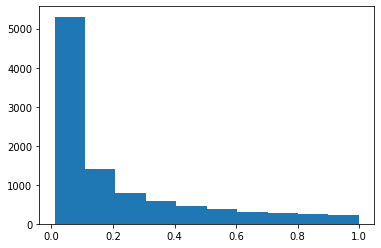

In [ ]:
from scipy import stats

dist = stats.norm(10, 2) # if you have a best guess (say: 10)

dist = stats.randint(1,100) # if you have no idea
dist = stats.uniform(1, 100) # same

dist = stats.loguniform(0.01, 1) # Coarse grain search

r = dist.rvs(size=10000) # Random draws
plt.hist(r);

`loguniform` great for coarse-grain search across several orders of magnitude

e.g. `loguniform(0.01, 1)` search over [$10^{-2}$, $10^{-1}$, $10^{0}$]
<table>
<tr>
    <td>
        <img src='https://docs.scipy.org/doc/scipy/_images/scipy-stats-loguniform-1_00_00.png'>
    </td>
    <td>
        <img src='https://docs.scipy.org/doc/scipy/_images/scipy-stats-loguniform-1_01_00.png'>
    </td>
</tr>
</table>

[Doc](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.loguniform.html)

### `RandomizedSearch` vs `GridSearch`

👉 Randomized Search:
- Less typing, if you want to try many values
- Control for the number of combinations to try / search time
- Useful when some hyperparams are more important than others

<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/grid_vs_random_search.png' width=500 style='margin:auto'> 

In any case:  
✅ Always start with a coarse grain approach (can use Grid or RandomSearch)  
✅ Then afterwards, fine-tune your search  

### 🔥 Key Summary 🔥

<hr>

👉 **FIT** = finding best **PARAMS** so as to minimize **LOSS**

👉 **FINETUNE** = finding best **HYPERPARAMS** so as to maximize **PERF METRIC**

<hr>

## 4. Support Vector Machines (SVMs) 

#### What's a good decision boundary for classification?

![decision boundary](https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/SVM_planes.png)

Infinite number of potential decision boundaries that separate the classes ("hyperplanes")

![margin](https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/SVM_margin.png)

- The hyperplane that generalizes best to unseen data is the one that is furthest from all the points (maximizes the **margin**)
- The points on the margin boundary are called **support vectors**
- Finding them is a convex optimization problem (one single best solution)  
- --> **Maximum Margin Classifier** algorithm 

🤔 When would such a model be problematic?

- Max Margin is super sensitive to outliers
- It **overfits** to the training data

For **generalization** purpose, we may want to allow some points to be **inside** the margin, or even **on the other side** of the decision boundary:

<img src="https://miro.medium.com/max/700/1*M_3iYollNTlz0PVn5udCBQ.png" width=400>

### 👉 Soft margin classifier

Allows a few points to be misclassified but with a **penalty($\color{blue}\xi$)**

Penalty for how "far" (<font color="blue" size=4>$\xi$</font>) they lie on the wrong side of the margin

The **Hinge Loss** is the penalty applied to each point on the wrong side

- The deeper a point lies within the margin, the higher the loss
- The penalty is linear, like MAE

<table>
    <tr>
        <td>
            <img src="https://miro.medium.com/max/700/1*M_3iYollNTlz0PVn5udCBQ.png" width=300>
        </td>
        <td>
            <img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/hinge_loss_.png' width=300>
        </td>
    </tr>
</table>

❓ **How strong** should the penalty be for wrongly classified datapoints?  
$\leftrightarrow$ How steep should the hinge loss be?  
$\leftrightarrow$ How narrow should the margin be?

**Tradeoff** between classifying training data well and generalizing to new data

Bias vs. Variance tradeoff again!
- Solution? **Regularization**

### Regulariation hyperparameter `C`

Strength of the penalty applied on points located on the wrong side of the margin

- The higher `C`, the stricter the margin
- A "maximum margin classifier" has `C` = $+ \infty$


- The smaller `C`, the softer the margin, the more it is **regularized**
- C is similar to $1/\alpha$ in Ridge 

<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/svm_regularization.png'>

💻 sklearn implementation

In [ ]:
from sklearn.svm import SVC
svc = SVC(kernel='linear', C=10)

# equivalent but with SGD solver
from sklearn.linear_model import SGDClassifier
svc_bis = SGDClassifier(loss='hinge', penalty='l2', alpha=1/10)

⚠️ Warning: All support vector models require **scaling**

<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/svm_scaling.png'>

### (Bonus) SVM Regressors

The trick is to reverse the objective:
- **Classification**: fit the largest possible _street_ **between** two classes
- **Regression**: fit as many points as possible **within** the _street_
- Width of the street controlled by an additional hyperparam `epsilon` $\epsilon$
<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/svm_regressor.png' >

```python
from sklearn.svm import SVR
regressor = SVR(epsilon=0.1, C=1, kernel='linear')
```

## 5. SVM Kernels (keep for recap only 🕚)

Fitting a **Linear SVM** is finding the best vector **w**

<center><img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/svm_hyperplane.png" width=400></center>

- whose **direction** uniquely determines the decision boundary hyperplane (orthogonal)
- which minimizes the sum of **hinge losses** for outliers

👉 **w** contains all inner params of the model computed during `.fit()`  
👉 `C` is the **cost** associated with the **wrong** classification

$$\\Loss(\textbf{w}, X) = C \sum_{i=1}^{n} HingeLoss(\textbf{w}, X_i) + ||\textbf{w}||^2 $$

#### What about this?

<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/SVM_nonlin.png'>

Non-linearly separable!

We could add a new feature $ Z = (X^2+Y^2) $

In a higher dimension, the data becomes **linearly** separable again!

<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/SVM_kernel1.png'>

What we just did is a **feature mapping $\phi$** from 2D to 3D

$\phi(\begin{bmatrix} x_1\\ x_2 \end{bmatrix}) = \begin{bmatrix} x_1 \\ x_2 \\ x_1^2 + x_2^2 \end{bmatrix}$

More precisely, a polynomial mapping of degree `d=2`

<br>
🤯 **Problem** 🤯 we have increased our feature space dimensionality  

Running an expensive SVM in higher dimensions can become extremely computer intensive

#### The Kernel Trick 🔥

Instead of explicitly creating all the new features, smart people came up with a very clever "trick":

- Each time the loss function is calculated, it calculates a sort of **similarity** $ K(\textbf{a},\textbf{b})$ between all pairs of datapoints, called a **Kernel**
- Two points with large similarity would be classified similarily
- We can **simulate** feature mapping by replacing the kernel wisely in the loss function
- Much more computationally **efficient**

📚 [Read more](https://xavierbourretsicotte.github.io/Kernel_feature_map.html)

#### SVM Kernels lists

`kernel` specifies the type of **feature mapping** to be used to make data **linearly separable** again
- `linear`
- `poly` (of dimension `d`)
- `rbf` (of coef `gamma`)
- `sigmoid` (of coef `gamma`)

`C` is the **strength** of the cost associated with the **wrong classification**

### 5.2 Kernel details

#### a) Linear Kernel

This is the hypothesis function $h_{\textbf{w}}(X)$ of a Linear SVM

$$ h_{\textbf{w}}(X) =
\begin{cases}
    0 \text{ if}\ \textbf{w}^T\textbf{x}  < -1 \\
    1 \text{ if}\ \textbf{w}^T\textbf{x}  ≥ 1
\end{cases}
$$


<center><img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/svm_hyperplane.png" width=200></center>

☝️ We say that the **Kernel** of Linear SVM is $ K(\textbf{a},\textbf{b}) = \textbf{a}^T\textbf{b}$

$ K(\textbf{a},\textbf{b}) = \textbf{a}^T\textbf{b}
\rightarrow \phi(x) = \begin{bmatrix} x_1 \\ x_2 \end{bmatrix}$


<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/SVM_kernel.png" width=600 >


💡Notice that $\textbf{w}^T \textbf{x}$ is proportional to the perpendicular distance $\color{blue}{d}$ to the decision boundary hyperplane

This distance is also called the **cosine similarity** between the two vectors

#### b) Polynomial Kernel (order 2)

$K(\textbf{a},\textbf{b}) = (\textbf{a}^T\textbf{b} + c )^2 \rightarrow \phi(x) = \begin{bmatrix} x_1^2 \\ x_1 x_2 \\ x_2 x_1 \\ x_2^2 \\  \sqrt{2c} \ x_1 \\ \sqrt{2c} \ x_2\end{bmatrix}$

**Polynomial Kernel order `d`**

$ K(\textbf{a},\textbf{b}) = (\textbf{a}^T\textbf{b} + c )^d $ 

Polynomial kernel also allows to fit non-linear **regression** very easily

<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/svm_regressor2.png' >

```python
regressor = SVR(epsilon=0.1, C=1, kernel='poly', degree=2)
```
Source: Hands-on ML with Sklearn (2020)

#### c) The RBF Kernel (aka Gaussian)

$K(\textbf{a},\textbf{b}) = \exp[ \left( - \gamma ||\textbf{a}-\textbf{b}||^2\right)$

Similarity between two datapoints is "gaussian"

Two points far away from one another are exponentially more likely to be different.

$\gamma$ acts as a _myopia_ factor.

👉 **Increasing $\gamma$ makes model overfit**

![RBF](https://miro.medium.com/max/700/1*r9CO-gp1uuRsYooCLL9UeQ.png)

## Recommanded read

- 📚 Hands-on Machine Learning with Sklearn (2020), Chapter 5 SVM Section "under the hood"
- [Kernel explained](https://xavierbourretsicotte.github.io/Kernel_feature_map.html) (Math)
- [SVM vs Logistic Regression](http://www.cs.toronto.edu/~kswersky/wp-content/uploads/svm_vs_lr.pdf) (Math)

# Your turn! 🚀